# Multi-Way PCA and PLS for Batch Data

After alignment, batch data is unfolded into a 2D matrix (observations × time×variables) for MPCA/MPLS.

`unfold_horizontal` returns a 3-tuple `(df, clbl, bid)` — not a plain DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyphi.batch as phibatch
import pyphi.plots as pp
from bokeh.io import output_notebook
output_notebook(hide_banner=True)
import pyphi.plots as _ppmod
_ppmod.output_file = lambda *a, **kw: None
%matplotlib inline


Will be using the NEOS server in the absence of IPOPT and GAMS


## Align Batch Data

In [2]:
bdata = pd.read_excel('../data/Batch Film Coating.xlsx')
samples_per_phase = {
    'STARTUP': 3, 'HEATING': 20, 'SPRAYING': 40,
    'DRYING': 40, 'DISCHARGING': 5
}
bdata_aligned = phibatch.phase_simple_align(bdata, samples_per_phase)

# Remove abnormal batches for NOC model
noc = bdata_aligned[~bdata_aligned.iloc[:, 0].isin(['B1905', 'B1805'])].copy()
dev = bdata_aligned[ bdata_aligned.iloc[:, 0].isin(['B1905', 'B1805'])].copy()
print('NOC batches:', noc.iloc[:, 0].unique().tolist())


NOC batches: ['B211', 'B311', 'B411', 'B1205', 'B1810', 'B1910', 'B2010', 'B2110', 'B2210', 'B2510', 'B2705', 'B2710', 'B2805', 'B2810', 'B2910']


## Build MPCA Model

In [3]:
mpca_obj = phibatch.mpca(noc, 2, phase_samples=samples_per_phase, cross_val=5)
print('Keys:', list(mpca_obj.keys()))


Cross validating PC #1
Cross validating PC #2


phi.pca using NIPALS and cross validation (5%) executed on: 2026-03-27 00:38:08.516762
--------------------------------------------------------------
PC #          Eig      R2X     sum(R2X)      Q2X     sum(Q2X)
PC #1:    160.232    0.225     0.225       0.034     0.034
PC #2:    101.622    0.143     0.368       0.198     0.232
--------------------------------------------------------------
Keys: ['T', 'P', 'r2x', 'r2xpv', 'mx', 'sx', 'var_t', 'obsidX', 'varidX', 'T2', 'T2_lim99', 'T2_lim95', 'speX', 'speX_lim99', 'speX_lim95', 'q2', 'q2pv', 'type', 'bid', 'uf', 'phase_samples', 'nvars', 'nbatches', 'nsamples', 'ninit', 'A']


## Score Plot and Diagnostics

In [4]:
pp.score_scatter(mpca_obj, [1, 2], add_labels=True)
pp.diagnostics(mpca_obj)


## R² per Variable and Loadings

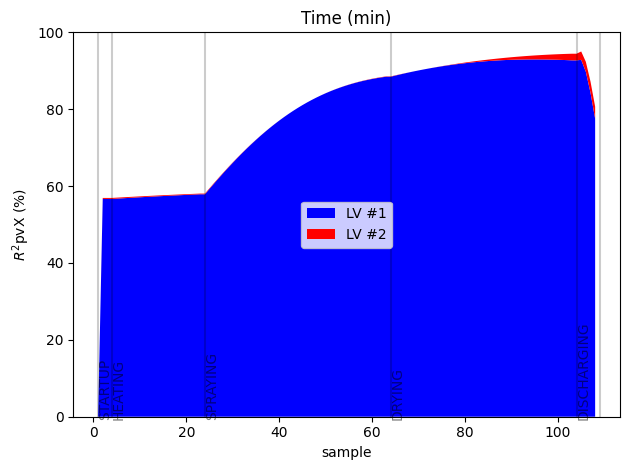

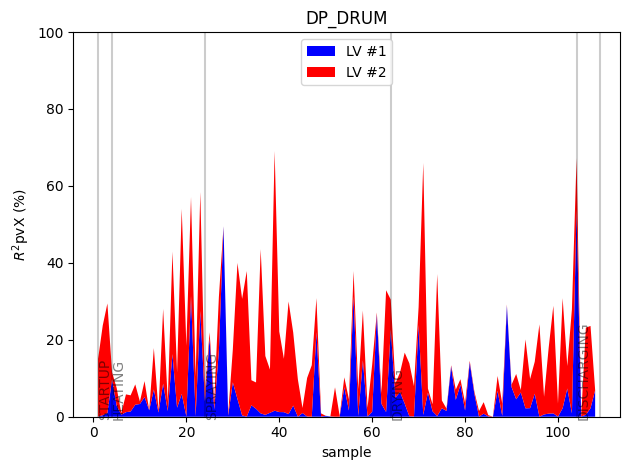

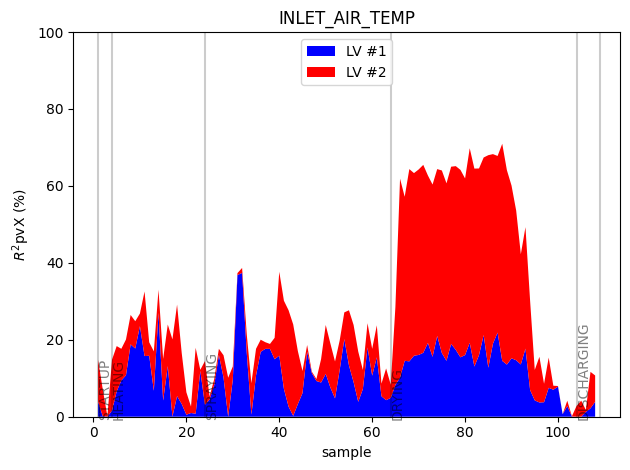

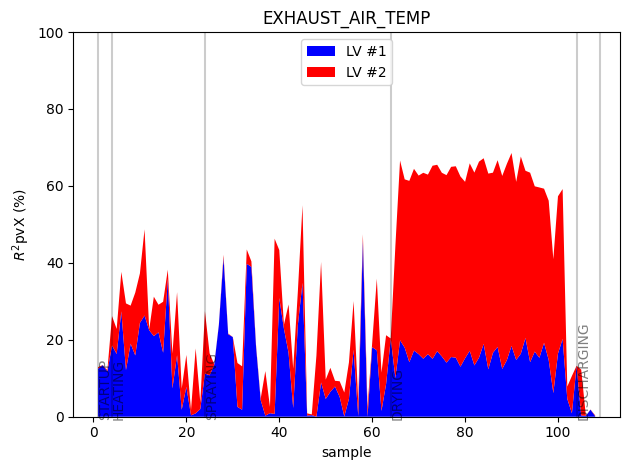

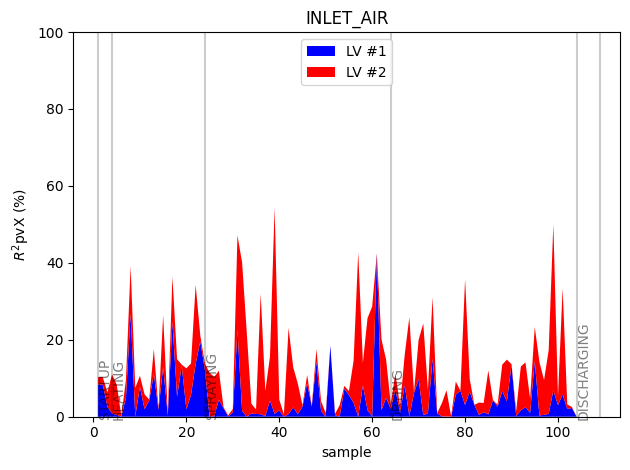

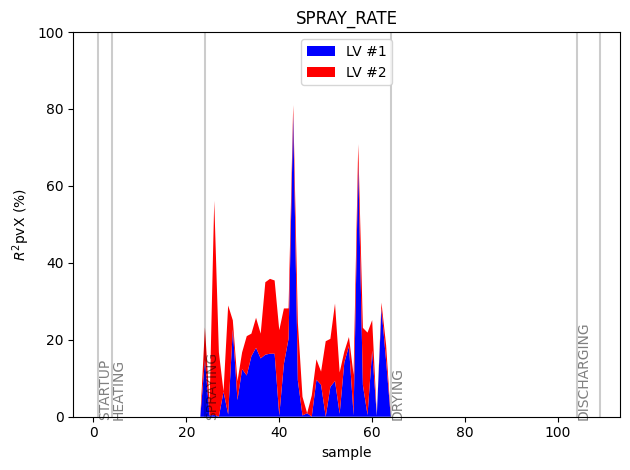

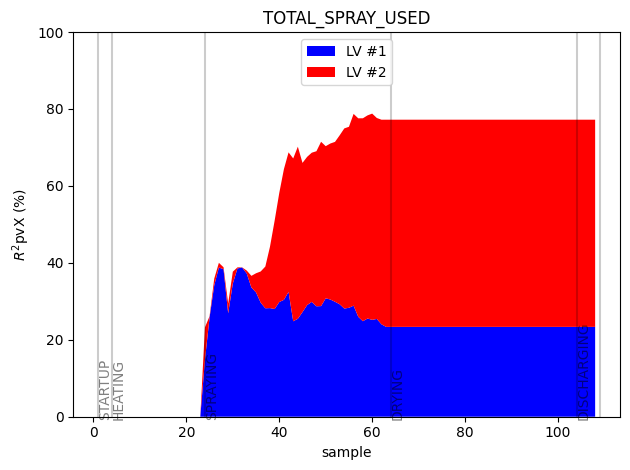

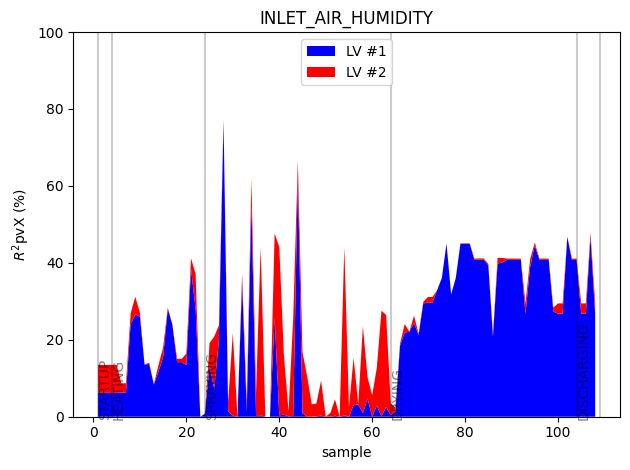

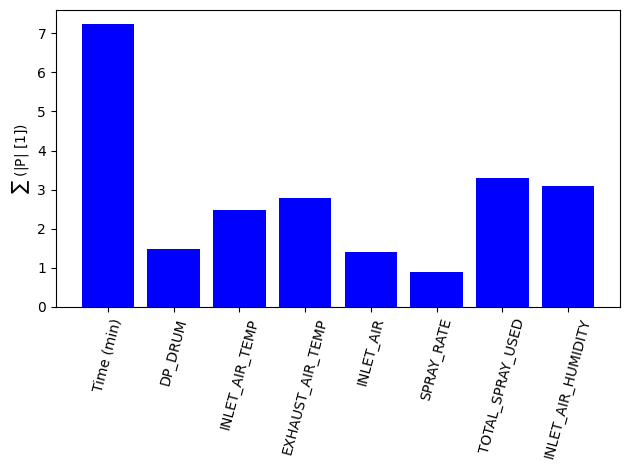

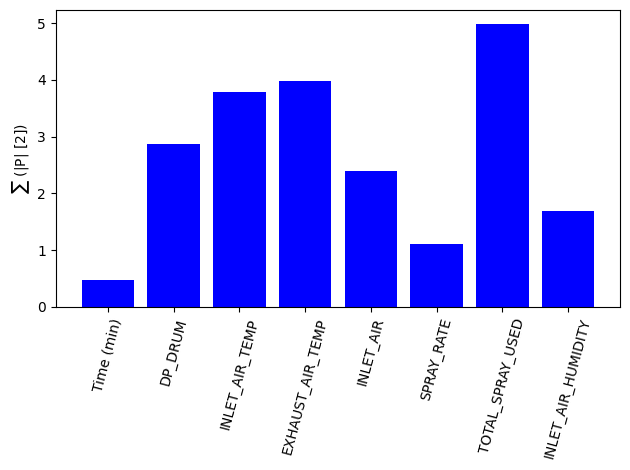

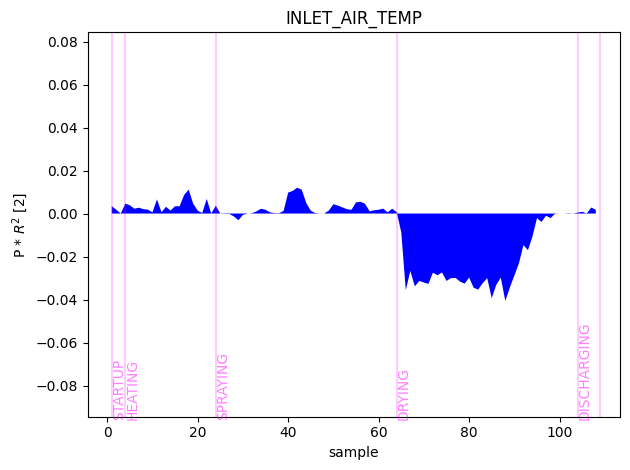

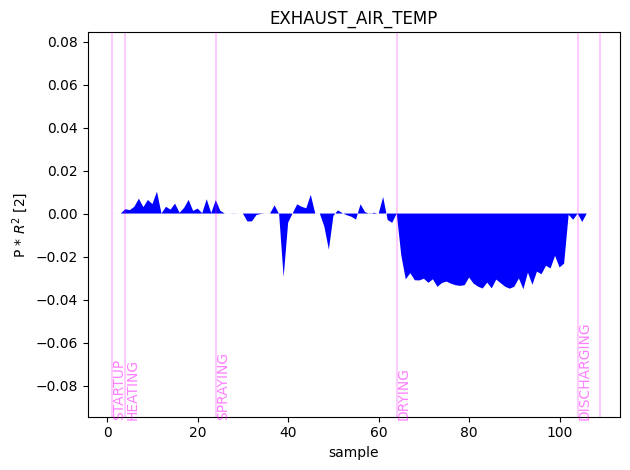

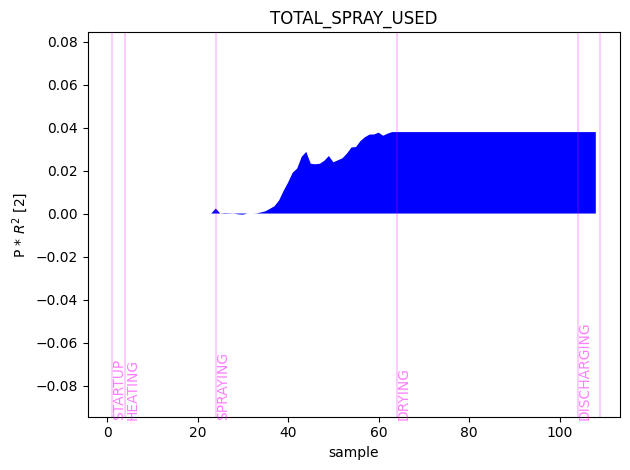

In [5]:
phibatch.r2pv(mpca_obj)
pp.r2pv(mpca_obj, plotwidth=1500)
phibatch.loadings_abs_integral(mpca_obj)
phibatch.loadings(mpca_obj, 2,
                  which_var=['INLET_AIR_TEMP', 'EXHAUST_AIR_TEMP', 'TOTAL_SPRAY_USED'],
                  r2_weighted=True)


## Batch Contributions

No dimensions specified, doing contributions across all dimensions
No dimensions specified, doing contributions across all dimensions


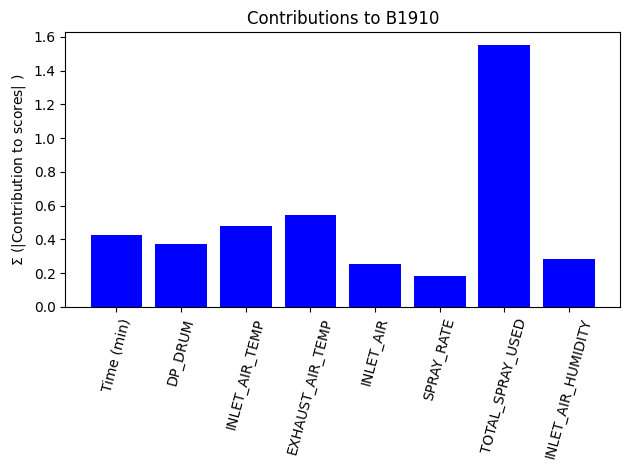

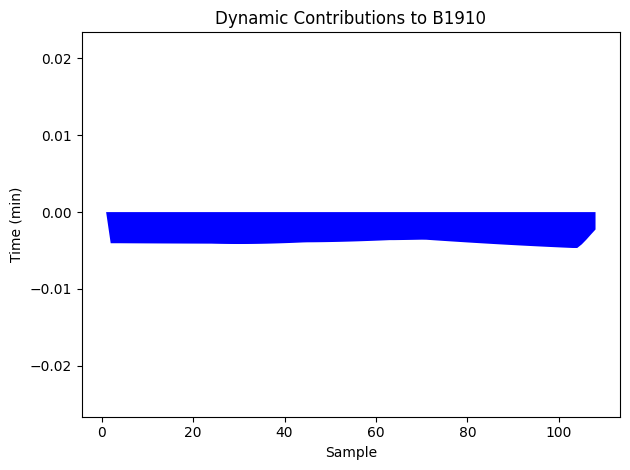

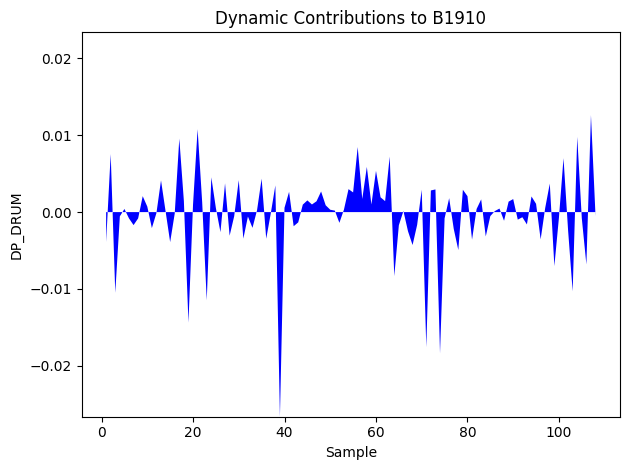

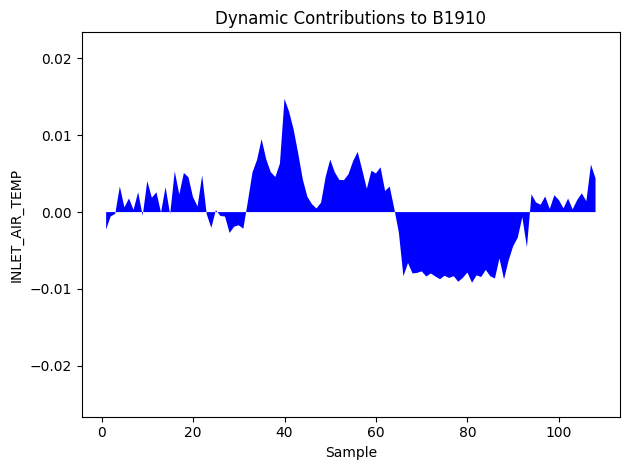

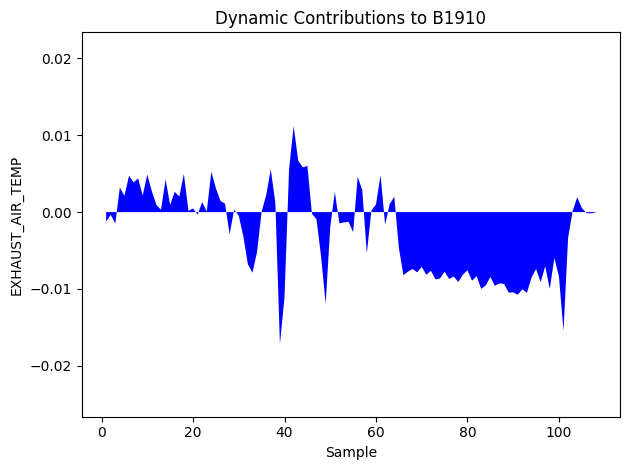

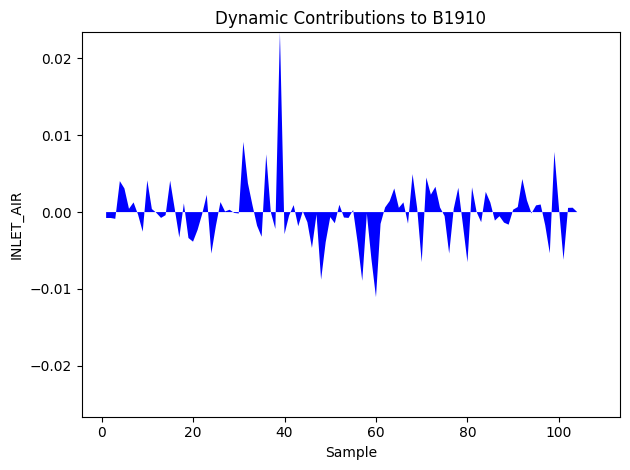

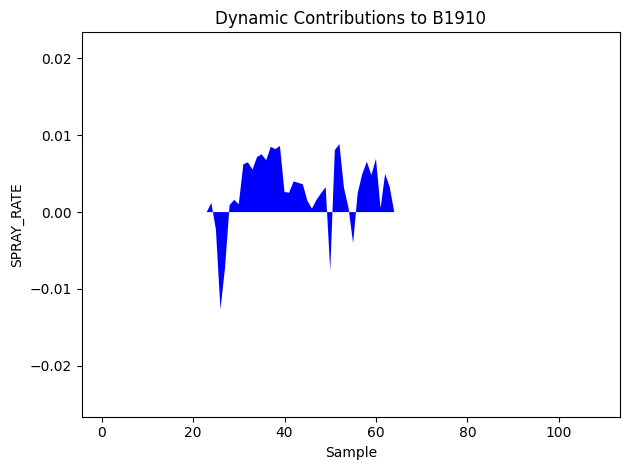

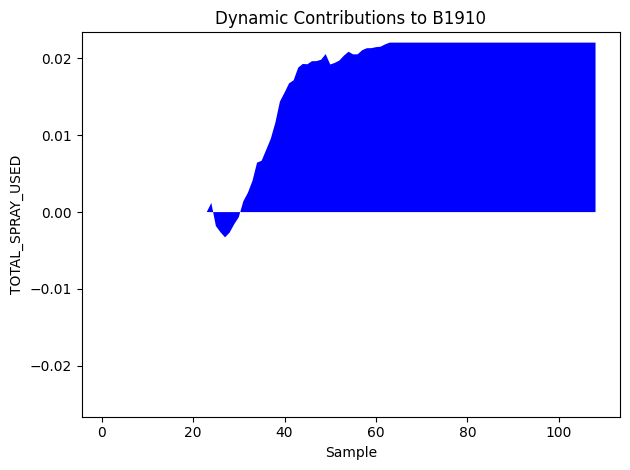

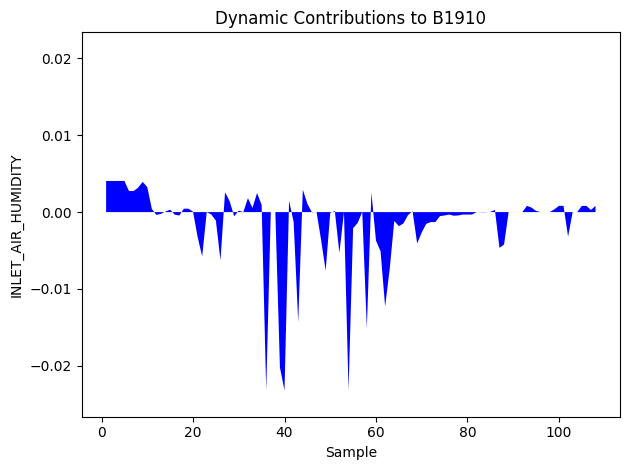

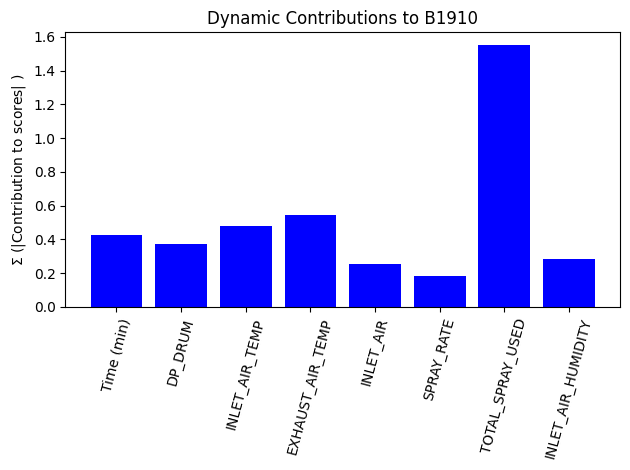

In [6]:
phibatch.contributions(mpca_obj, noc, 'scores', to_obs=['B1910'],
                       plot_title='Contributions to B1910')
phibatch.contributions(mpca_obj, noc, 'scores', to_obs=['B1910'],
                       dyn_conts=True, plot_title='Dynamic Contributions to B1910')


## Build MPLS Model (Dryer Dataset)

MPLS predicts end-of-batch quality from trajectory data.

phi.pls using NIPALS executed on: 2026-03-27 00:38:12.824912
# Iterations for LV #1:  32
# Iterations for LV #2:  35
# Iterations for LV #3:  21
--------------------------------------------------------------
LV #     Eig       R2X       sum(R2X)   R2Y       sum(R2Y)
LV #1:   86.793    0.122     0.122      0.229     0.229
LV #2:   133.694    0.160     0.281      0.071     0.300
LV #3:   51.590    0.067     0.349      0.109     0.409
--------------------------------------------------------------
MPLS Keys: ['T', 'P', 'Q', 'W', 'Ws', 'U', 'r2x', 'r2xpv', 'mx', 'sx', 'r2y', 'r2ypv', 'my', 'sy', 'var_t', 'obsidX', 'varidX', 'obsidY', 'varidY', 'T2', 'T2_lim99', 'T2_lim95', 'speX', 'speX_lim99', 'speX_lim95', 'speY', 'speY_lim99', 'speY_lim95', 'type', 'Yhat', 'bid', 'uf', 'nvars', 'nbatches', 'nsamples', 'A', 'phase_samples', 'mb_each_var', 'ninit']


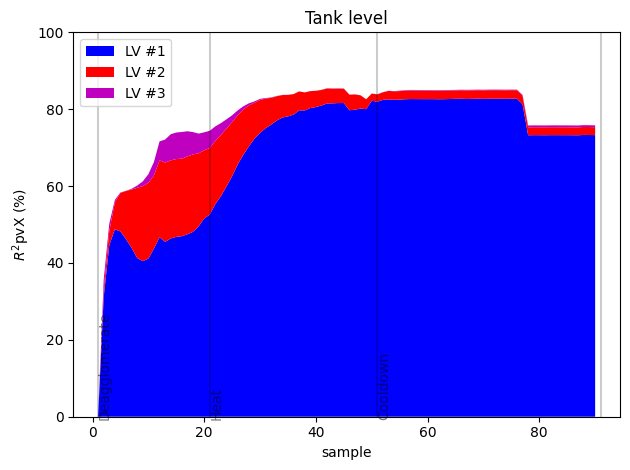

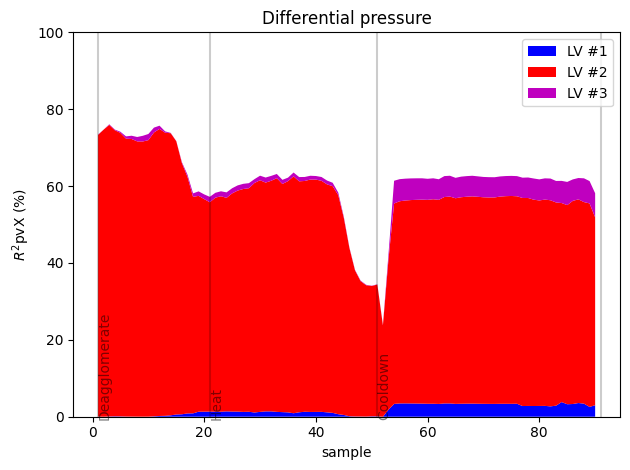

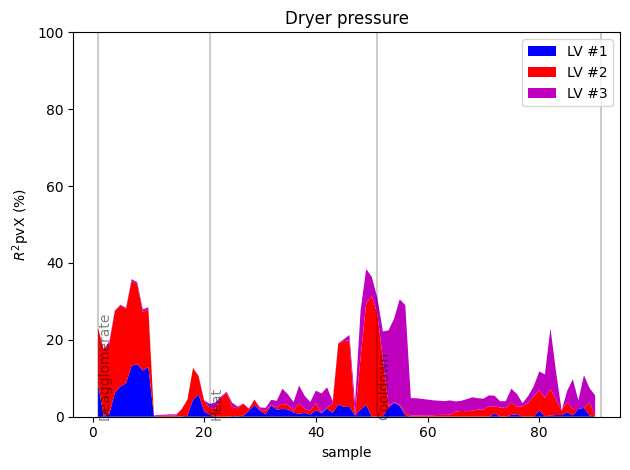

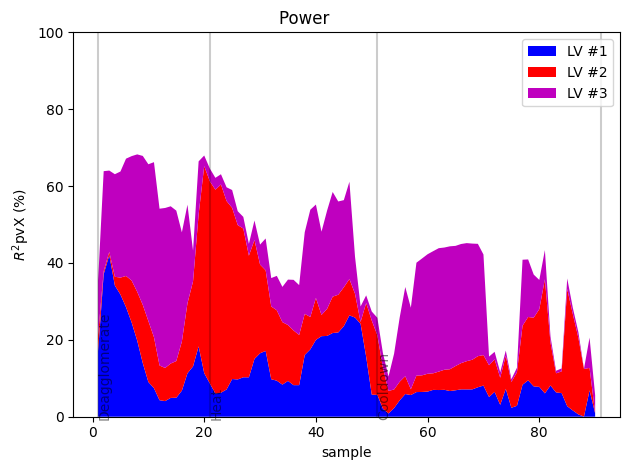

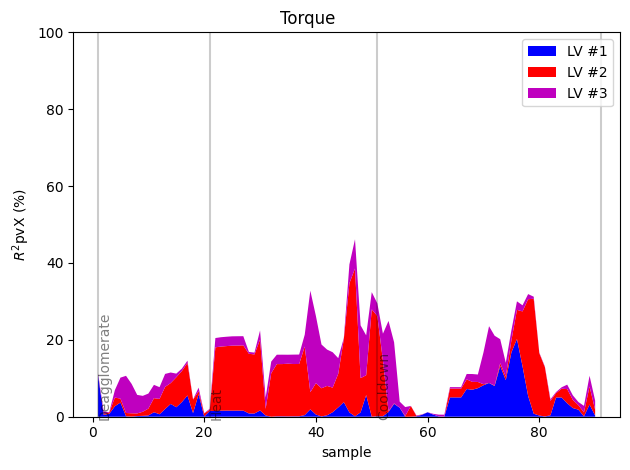

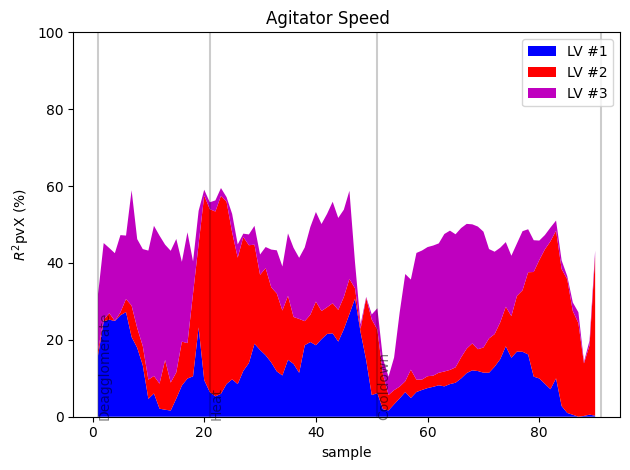

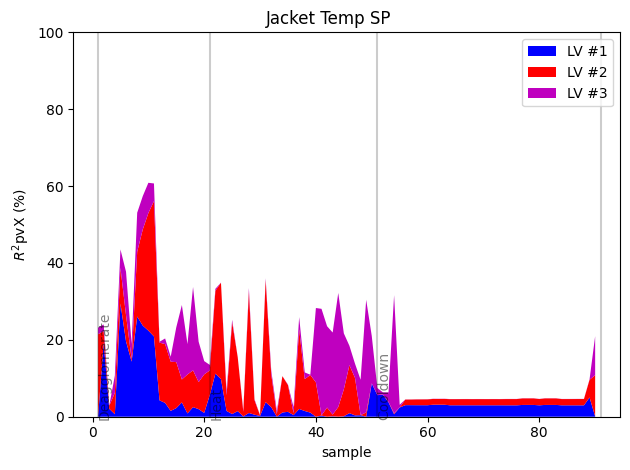

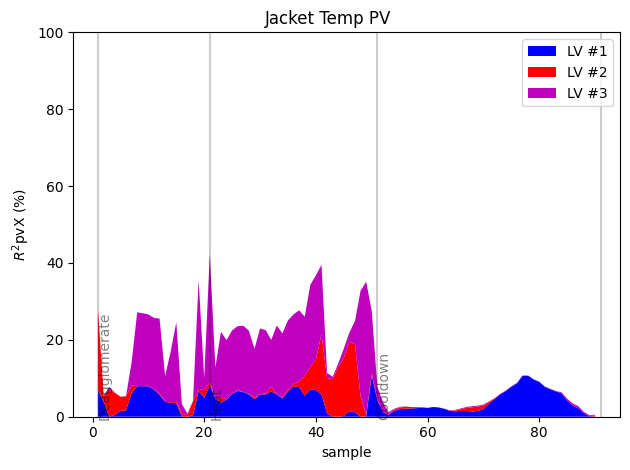

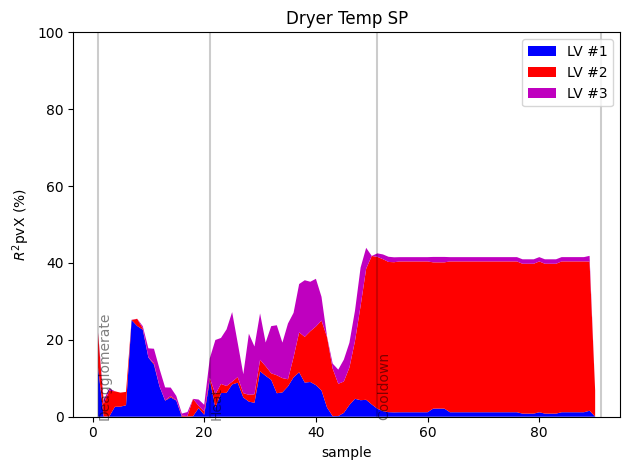

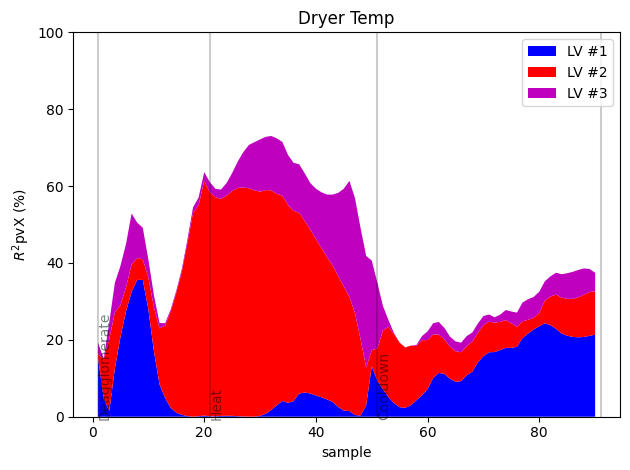

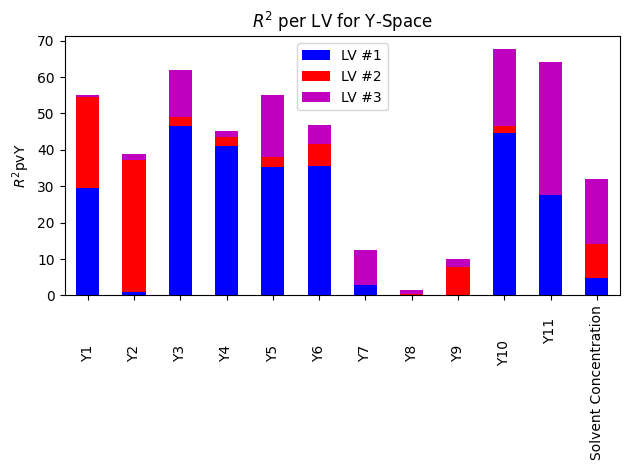

In [7]:
bdata_d = pd.read_excel('../data/Batch Dryer Case Study.xlsx', sheet_name='Trajectories')
cqa     = pd.read_excel('../data/Batch Dryer Case Study.xlsx', sheet_name='ProductQuality')
samples_d = {'Deagglomerate': 20, 'Heat': 30, 'Cooldown': 40}

bdata_d_aligned = phibatch.phase_simple_align(bdata_d, samples_d)
mpls_obj = phibatch.mpls(bdata_d_aligned, cqa, 3, phase_samples=samples_d)
print('MPLS Keys:', list(mpls_obj.keys()))
phibatch.r2pv(mpls_obj)
